# Baseline Experiment Comparison

Compare metrics and dataset scope across `exp_001`, `exp_002`, and `exp_003`.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('../../').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from evaluation.comparison import DEFAULT_EXPERIMENTS, load_comparison_frames

plt.style.use('seaborn-v0_8-whitegrid')

SOURCE_MODE = 'auto'
EXPERIMENTS = DEFAULT_EXPERIMENTS

EXPORT_DIR = REPO_ROOT / 'evaluation/tmp/notebook_exports/01_experiment_comparison'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_DIR_GR = REPO_ROOT / 'evaluation/graphics'
EXPORT_DIR_GR.mkdir(parents=True, exist_ok=True)


In [2]:
frames = load_comparison_frames(EXPERIMENTS, source_mode=SOURCE_MODE)
holdout_metrics = frames['holdout_metrics']
split_summary = frames['split_summary']
rolling_summary = frames['rolling_summary']
dataset_summary = frames['dataset_summary']


In [3]:
holdout_metrics.to_csv(EXPORT_DIR / 'holdout_metrics_comparison.csv', index=False)
split_summary.to_csv(EXPORT_DIR / 'split_summary_comparison.csv', index=False)
if not rolling_summary.empty:
    rolling_summary.to_csv(EXPORT_DIR / 'rolling_aggregate_comparison.csv', index=False)
if not dataset_summary.empty:
    dataset_summary.to_csv(EXPORT_DIR / 'dataset_summary_comparison.csv', index=False)
holdout_metrics


,experiment,model,mae,rmse,directional_accuracy,spearman_corr
0,exp_001,naive_lag1,0.008867,0.012713,0.591137,0.131772
1,exp_001,linear_regression,0.006824,0.009615,0.618395,0.180810
2,exp_002,naive_lag1,0.001965,0.002329,0.800000,0.006061
3,exp_002,linear_regression,0.001663,0.002070,0.900000,0.139394
4,exp_003,naive_lag1,0.012841,0.016136,0.547619,0.070532
5,exp_003,linear_regression,0.009354,0.011940,0.574405,0.132672


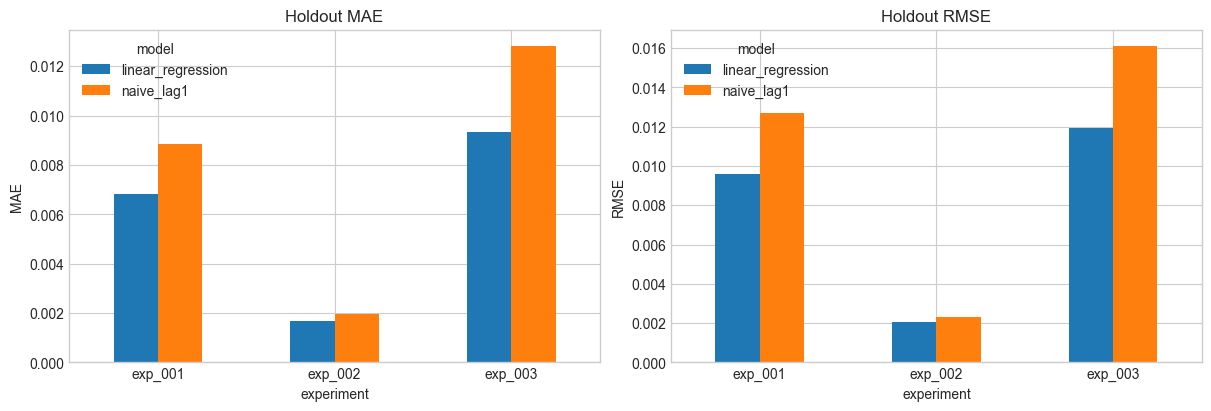

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,4), constrained_layout=True)
for ax,metric,title in [(axes[0],'mae','Holdout MAE'), (axes[1],'rmse','Holdout RMSE')]:
    holdout_metrics.pivot(index='experiment', columns='model', values=metric).plot(kind='bar', ax=ax, rot=0)
    ax.set_ylabel(metric.upper()); ax.set_title(title)
fig.savefig(EXPORT_DIR_GR / 'holdout_error_bars.png', dpi=150, bbox_inches='tight')
plt.show()

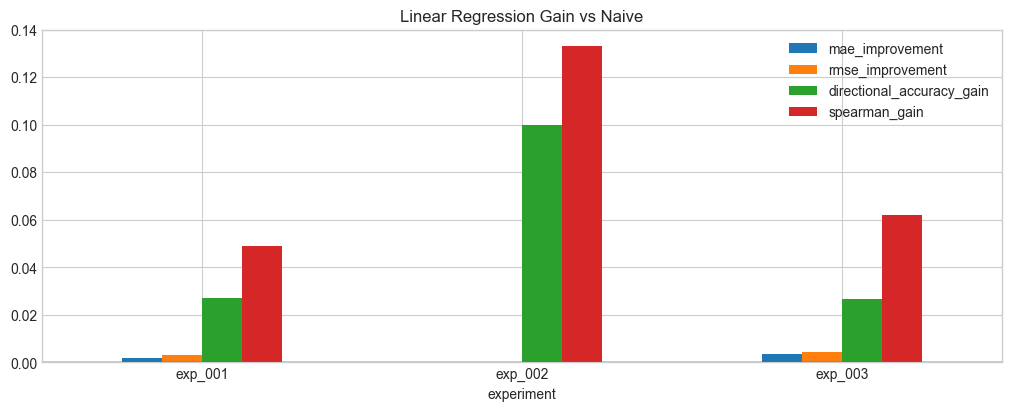

,mae_improvement,rmse_improvement,directional_accuracy_gain,spearman_gain
experiment,,,,
exp_001,0.002043,0.003098,0.027258,0.049038
exp_002,0.000302,0.000259,0.100000,0.133333
exp_003,0.003487,0.004196,0.026786,0.062140


In [5]:
p = holdout_metrics.pivot(index='experiment', columns='model', values=['mae','rmse','directional_accuracy','spearman_corr'])
delta = pd.DataFrame({
    'mae_improvement': p[('mae','naive_lag1')] - p[('mae','linear_regression')],
    'rmse_improvement': p[('rmse','naive_lag1')] - p[('rmse','linear_regression')],
    'directional_accuracy_gain': p[('directional_accuracy','linear_regression')] - p[('directional_accuracy','naive_lag1')],
    'spearman_gain': p[('spearman_corr','linear_regression')] - p[('spearman_corr','naive_lag1')],
})
fig, ax = plt.subplots(figsize=(10,4), constrained_layout=True)
delta.plot(kind='bar', ax=ax, rot=0)
ax.axhline(0.0, color='black', linewidth=1); ax.set_title('Linear Regression Gain vs Naive')
fig.savefig(EXPORT_DIR_GR / 'model_gain_vs_naive.png', dpi=150, bbox_inches='tight')
plt.show()
delta


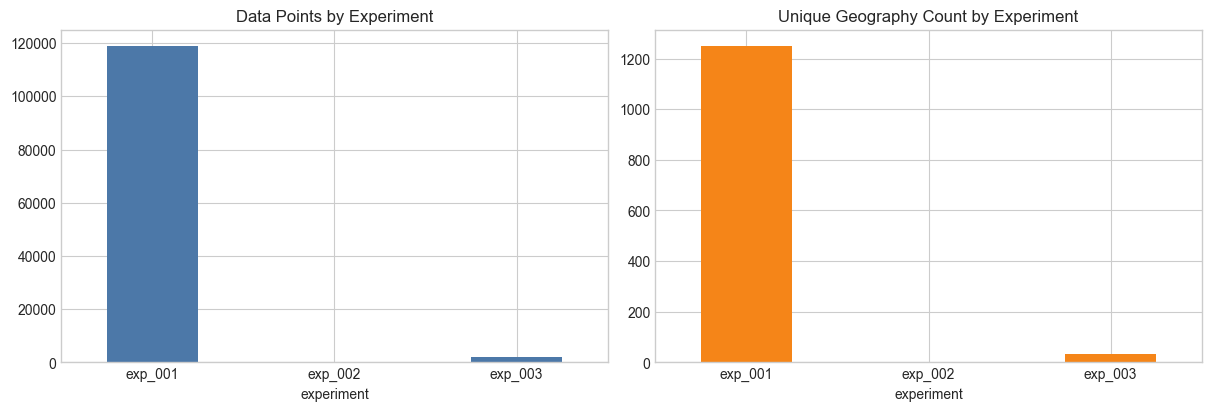

In [6]:
if not dataset_summary.empty and {'experiment','row_count','geo_count'}.issubset(dataset_summary.columns):
    ds = dataset_summary[['experiment','row_count','geo_count']].set_index('experiment')
    fig, axes = plt.subplots(1,2, figsize=(12,4), constrained_layout=True)
    ds['row_count'].plot(kind='bar', ax=axes[0], rot=0, color='#4C78A8'); axes[0].set_title('Data Points by Experiment')
    ds['geo_count'].plot(kind='bar', ax=axes[1], rot=0, color='#F58518'); axes[1].set_title('Unique Geography Count by Experiment')
    fig.savefig(EXPORT_DIR_GR / 'dataset_scope_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('dataset_summary missing row_count/geo_count')
